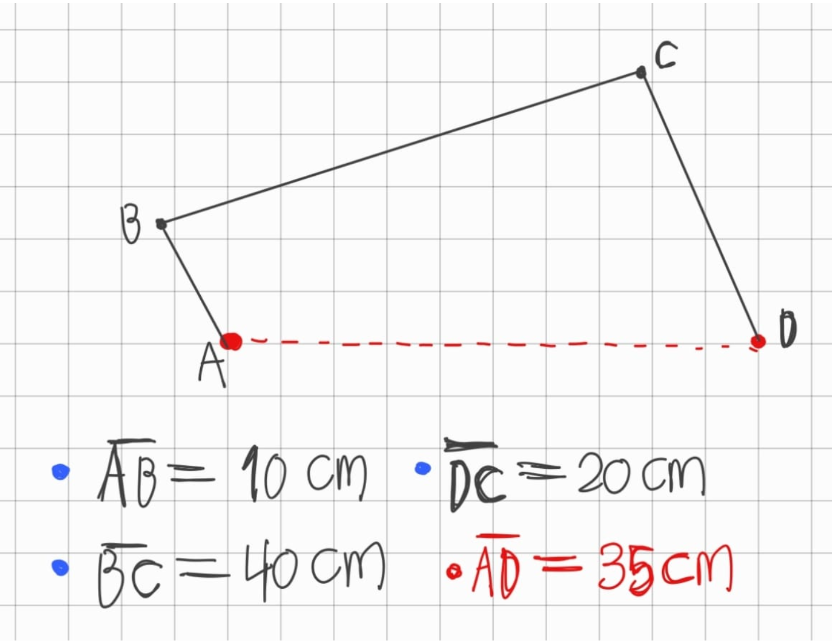


Sergio Emanuel Ropero - 202120446

### ¿Cuantos grados de libertad tiene?

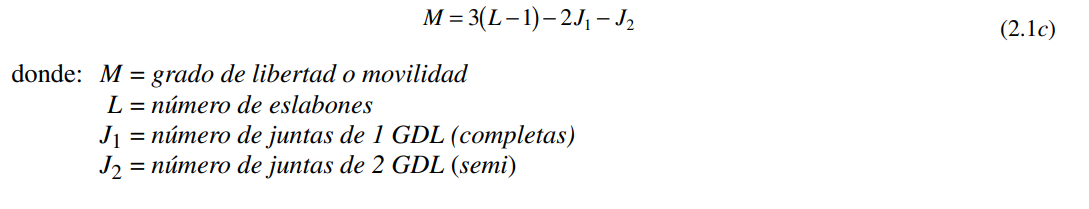

### 1. Cinematica Directa 

grafique el PUNTO C en coordenadas X y Y, cuando la entrada del sistema esta dado por: 

$$
\theta(t) = \pi/2 ( 1 + \sin(5t))
$$



In [86]:
import sympy as sp
from sympy import symbols
from sympy.physics.mechanics import dynamicsymbols, ReferenceFrame
import numpy as np
import scipy.optimize as opt

theta, theta1, theta2 = dynamicsymbols('theta theta1 theta2')

L1, L2, L3, L4 = symbols('L1 L2 L3 L4', positive=True)

N = ReferenceFrame('N')
A = N.orientnew('A', 'Axis', [sp.pi - theta, N.z])
B = N.orientnew('B', 'Axis', [theta1, N.z])
C = N.orientnew('C', 'Axis', [-theta2, N.z])

eqLoop = A.x*L1 + B.x*L2 + C.x*L3 - N.x*L4
eqN = eqLoop.express(N)

params = {L1: 0.1, L2: 0.4, L3: 0.2, L4: 0.35}
eqnum = eqN.subs(params)

fun = sp.lambdify((theta, theta1, theta2),(eqnum.dot(N.x), eqnum.dot(N.y)))

t = np.linspace(0, 10, 100)

theta_vals = np.pi / (2 * (1 + np.sin(5 + t)))

x0 = np.array([np.deg2rad(60.0), np.deg2rad(60.0)], dtype=float)
theta1_sol = []
theta2_sol = []
for th in theta_vals:
    myfun = lambda x: np.array(fun(th, x[0], x[1]), dtype=float)
    sol = scipy.optimize.fsolve(myfun, x0)
    theta1_sol.append(sol[0])
    theta2_sol.append(sol[1])
    print(np.rad2deg(sol)) 

[20.33300783 72.37006789]
[ 13.57728264 119.65183345]
[18.08661882 78.68752169]
[ 20.93290973 127.74589999]
[20.24095877 72.58955786]
[40.36832451 60.59975476]
[45.69146338 83.65328071]
[ 31.93308675 115.06573159]
[ 19.28325376 128.51236001]
[ 14.69207497 125.2879938 ]
[ 13.43969452 117.98792364]
[ 13.31832168 110.83279684]
[ 13.61793537 104.69417145]
[14.07722563 99.62001042]
[14.58559928 95.47022217]
[15.09196855 92.08097015]
[15.57189111 89.30706716]
[16.01393713 87.02988628]
[16.41337343 85.15544499]
[16.76898612 83.61019504]
[17.08138571 82.33684148]
[17.35206671 81.29082273]
[17.58287359 80.43752858]
[17.77569431 79.7501657 ]
[17.93228467 79.20814722]
[18.05416903 78.79589371]
[18.14258542 78.50195437]
[18.19845645 78.31838009]
[18.22237464 78.24029881]
[18.21459574 78.26566002]
[18.17503645 78.39512831]
[18.1032751  78.63211778]
[17.99855581 78.98297003]
[17.85979852 79.45728938]
[17.68561968 80.06846184]
[17.47437217 80.83439847]
[17.22421909 81.77856154]
[16.93326541 82.931352

Text(0, 0.5, 'y')

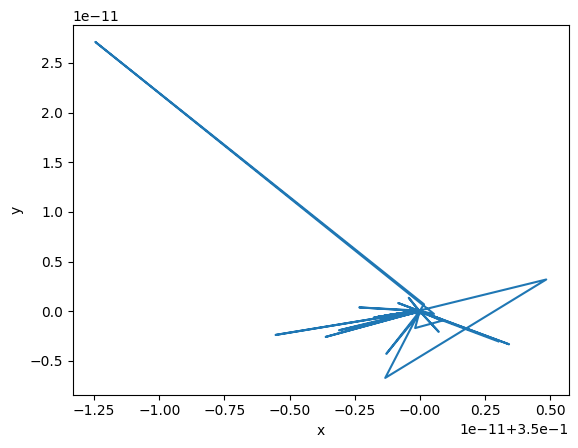

In [87]:
pos_c = A.x*L1 + B.x*L2 + C.x*L3
pos_c_x = pos_c.dot(N.x).subs(params)
pos_c_x_i = [pos_c_x.subs(theta, theta_vals[i]).subs(theta1, theta1_sol[i]).subs(theta2, theta2_sol[i]) for i in range(len(theta_vals))]
pos_c_y = pos_c.dot(N.y).subs(params)
pos_c_y_i = [pos_c_y.subs(theta, theta_vals[i]).subs(theta1, theta1_sol[i]).subs(theta2, theta2_sol[i]) for i in range(len(theta_vals))]
plt.plot(pos_c_x_i, pos_c_y_i)
plt.xlabel('x')
plt.ylabel('y')

### 2. Cinematica inversa 

¿cual es el valor de $\theta_1$ para que el punto C este en x = 35 cm y Y = 20 cm

¿se puede llegar al valor exacto?, Explique porqué



In [88]:
eqLoop = A.x*L1 + B.x*L2 + C.x*L3
eqN = eqLoop.express(N)

params = {L1: 0.1, L2: 0.4, L3: 0.2, L4: 0.35}
eqnum = eqN.subs(params)

fun = sp.lambdify((theta, theta1, theta2),(eqnum.dot(N.x), eqnum.dot(N.y)))

x0 = np.array([np.deg2rad(60.0), np.deg2rad(60.0)], dtype=float)

# (Opcional) límites de ángulos
bnds = [(-np.pi, np.pi), (-np.pi, np.pi)]
theta1_sol = []
theta2_sol = []
def cost(x):
    fx, fy = fun(th, x[0], x[1])
    return float(fx*fx + fy*fy)

res = scipy.optimize.minimize(cost, x0, method="L-BFGS-B", bounds=bnds)

sol = res.x
np.rad2deg(sol)[0]




np.float64(-17.519146861410707)

## BONO : 
### DIBUJE LA PRIMERA LETRA DE SU NOMBRE UTILIZANDO LA PUNTA DEL ROBOT RRR

*Cada eslabon mide 10 cm*

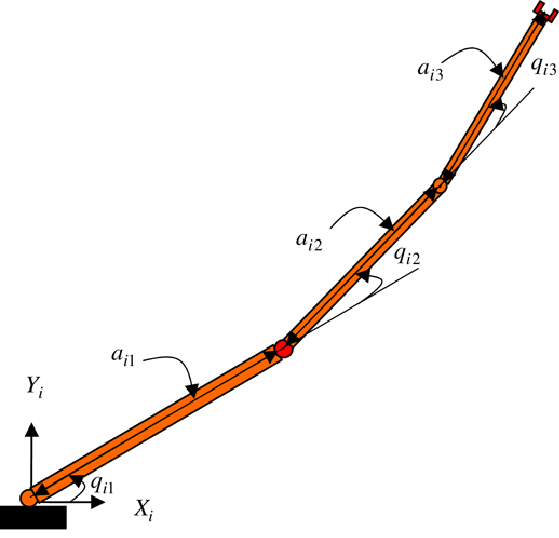

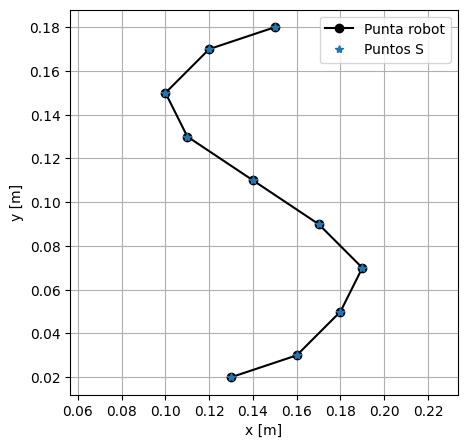

Ángulos en grados:
[[  41.10946055   62.69781431  -93.93824661]
 [  35.64028134   88.99422104 -107.50627024]
 [  50.89318306   78.10957492 -132.04581771]
 [  45.48170647   79.53792796 -138.43343236]
 [ -48.91896848  113.98984908    6.1828644 ]
 [ -21.4516174   122.38071835  -84.43879393]
 [ -11.95598817  106.21361229  -99.42582816]
 [   5.88110655   83.71216722 -126.63807611]
 [ -47.58703639  141.80934278  -91.87153397]
 [ -55.16023103  160.80124928 -102.32841048]]
Error RMS aproximado [m]: 1.1767738737651745e-07


In [89]:

q1, q2, q3 = dynamicsymbols('q1 q2 q3')
L1, L2, L3 = symbols('L1 L2 L3', positive=True)

N = ReferenceFrame('N')
A1 = N.orientnew('A1', 'Axis', [q1, N.z])
A2 = N.orientnew('A2', 'Axis', [q1 + q2, N.z])
A3 = N.orientnew('A3', 'Axis', [q1 + q2 + q3, N.z])

r = L1*A1.x + L2*A2.x + L3*A3.x
rN = r.express(N)

x_expr = sp.simplify(rN.dot(N.x))
y_expr = sp.simplify(rN.dot(N.y))

# Función FK numérica
fk = sp.lambdify((q1, q2, q3, L1, L2, L3), (x_expr, y_expr), modules='numpy')


L1v = L2v = L3v = 0.10  



def solve_ik_point(xd, yd, q_init):
    def residual(q):
        x, y = fk(q[0], q[1], q[2], L1v, L2v, L3v)
        return np.array([x - xd, y - yd], dtype=float)

    res = least_squares(
        residual,
        q_init,
        bounds=([-np.pi]*3, [np.pi]*3)
    )
    return res.x, res.cost, res.success


points = np.array([
    [0.15, 0.18],
    [0.12, 0.17],
    [0.10, 0.15],
    [0.11, 0.13],
    [0.14, 0.11],
    [0.17, 0.09],
    [0.19, 0.07],
    [0.18, 0.05],
    [0.16, 0.03],
    [0.13, 0.02],
], dtype=float)



qs = []
xy_fk = []
costs = []

q0 = np.array([np.deg2rad(20),
               np.deg2rad(40),
               np.deg2rad(-30)], dtype=float)

for xd, yd in points:

    q_sol, cost, ok = solve_ik_point(xd, yd, q0)

    qs.append(q_sol)
    costs.append(cost)

    xf, yf = fk(q_sol[0], q_sol[1], q_sol[2], L1v, L2v, L3v)
    xy_fk.append([xf, yf])

qs = np.array(qs)
xy_fk = np.array(xy_fk)
costs = np.array(costs)

# Plot

plt.figure(figsize=(5,5))
plt.plot(xy_fk[:,0], xy_fk[:,1], 'k-o', label='Punta robot')
plt.plot(points[:,0], points[:,1], '*', label='Puntos S')

plt.axis('equal')
plt.grid(True)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.legend()
plt.show()


print("Ángulos en grados:")
print(np.rad2deg(qs))

print("Error RMS aproximado [m]:", np.sqrt(2*np.mean(costs)))